In [7]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd 
import numpy as np
%matplotlib inline


In [8]:
X,Y = make_blobs(n_samples=1000,centers=3,n_features=2)

In [9]:
X

array([[ 3.56855997, -0.3921512 ],
       [-1.56964665,  4.34378017],
       [ 4.19625868, -0.18558887],
       ...,
       [ 4.84383055, -2.19126075],
       [-2.33970251, -5.36042957],
       [-1.2395836 ,  5.92959938]])

In [10]:
Y

array([2, 1, 2, 0, 0, 1, 0, 0, 2, 1, 0, 2, 1, 2, 0, 2, 1, 0, 0, 1, 2, 0,
       1, 2, 0, 1, 0, 0, 1, 0, 1, 1, 2, 0, 2, 2, 0, 0, 1, 1, 2, 1, 2, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 2, 2, 1, 1, 0, 0, 0, 1, 2, 0, 0,
       1, 0, 1, 0, 0, 2, 2, 0, 0, 1, 2, 2, 1, 2, 1, 0, 1, 2, 0, 1, 2, 0,
       0, 1, 2, 0, 0, 0, 2, 0, 0, 1, 1, 2, 0, 1, 2, 0, 0, 0, 2, 1, 2, 0,
       1, 2, 1, 0, 0, 0, 1, 2, 2, 0, 1, 1, 2, 2, 2, 2, 1, 0, 2, 1, 2, 2,
       1, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 2, 2, 1, 0, 2,
       0, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2, 2, 0, 2, 0, 1, 2, 1, 2, 2, 1,
       1, 0, 0, 0, 2, 2, 0, 1, 0, 0, 1, 0, 1, 0, 1, 2, 0, 1, 1, 2, 0, 0,
       2, 2, 2, 2, 0, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 1, 1, 2, 0, 0, 0,
       0, 0, 2, 2, 1, 0, 0, 1, 2, 1, 0, 1, 1, 1, 0, 1, 2, 2, 1, 2, 1, 1,
       0, 1, 1, 0, 1, 2, 1, 0, 1, 2, 1, 1, 2, 1, 2, 0, 2, 0, 0, 0, 0, 2,
       2, 1, 2, 1, 2, 0, 0, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 1, 1, 1, 2,
       1, 2, 1, 2, 0, 2, 0, 1, 0, 2, 0, 0, 0, 1, 1,

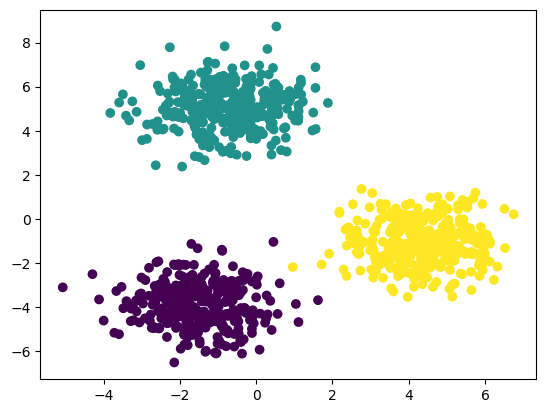

In [11]:
plt.scatter(X[:,0],X[:,1],c=Y)
plt.show()

In [12]:
## Standardization -- feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train,X_test,Y_train,Y_test = train_test_split( X,Y, test_size=0.33, random_state=42)

In [15]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.cluster import KMeans

In [17]:
print(X_train_scaled.shape)

(670, 2)


In [18]:
## Elbow method to select K value
wcss = []
for k in range (1,11):
  kmeans = KMeans(n_clusters=k,init="k-means++")
  kmeans.fit(X_train_scaled)
  wcss.append(kmeans.inertia_)

c:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

In [19]:
wcss

[1339.9999999999993,
 675.2792667185538,
 129.096744089468,
 112.31005035031768,
 107.1143203427679,
 89.28008725276696,
 80.15172468709292,
 62.991172657223814,
 54.96284967868093,
 53.33884139492619]

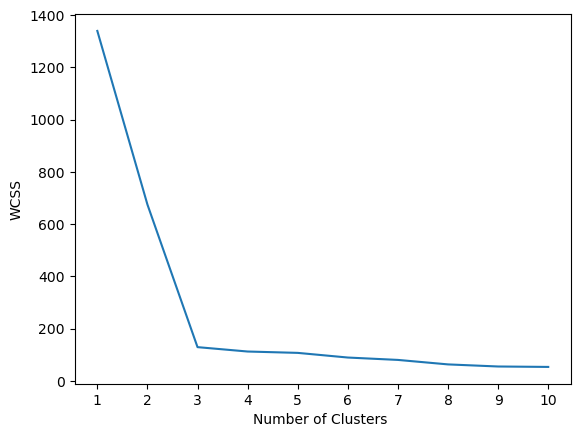

In [20]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters ")
plt.ylabel("WCSS")
plt.show()


In [21]:
kmeans = KMeans(n_clusters=3,init="k-means++")

In [22]:
kmeans.fit_predict(X_train)

c:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([2, 0, 2, 0, 2, 2, 2, 0, 0, 0, 2, 2, 0, 2, 0, 1, 1, 1, 2, 1, 2, 2,
       0, 1, 2, 2, 0, 1, 0, 1, 2, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 2,
       1, 2, 2, 1, 2, 1, 0, 0, 1, 1, 1, 2, 1, 0, 1, 1, 1, 0, 0, 2, 2, 2,
       0, 0, 2, 2, 1, 0, 1, 2, 2, 2, 2, 2, 1, 1, 0, 2, 0, 2, 1, 0, 2, 2,
       0, 1, 1, 2, 1, 2, 1, 0, 2, 1, 1, 1, 2, 2, 2, 1, 2, 0, 1, 1, 1, 2,
       2, 1, 1, 0, 2, 0, 0, 0, 1, 2, 0, 2, 2, 0, 0, 1, 2, 0, 2, 2, 1, 1,
       0, 2, 0, 1, 1, 2, 0, 2, 0, 1, 2, 0, 0, 1, 2, 2, 1, 1, 2, 2, 2, 0,
       2, 1, 2, 1, 1, 0, 1, 2, 1, 1, 2, 1, 1, 1, 0, 1, 2, 1, 1, 1, 0, 1,
       1, 2, 2, 2, 1, 0, 2, 2, 0, 2, 2, 1, 2, 0, 0, 1, 2, 0, 2, 1, 1, 2,
       2, 1, 0, 0, 1, 0, 0, 0, 2, 0, 1, 2, 0, 2, 2, 0, 2, 1, 0, 2, 2, 0,
       0, 0, 2, 0, 0, 2, 1, 2, 1, 2, 2, 0, 0, 2, 2, 1, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 1, 0, 1, 2, 0, 0, 0, 2, 0, 0, 2, 1, 0, 0, 1, 0, 0, 1,
       2, 1, 2, 2, 1, 1, 1, 1, 2, 0, 1, 2, 0, 1, 2, 1, 2, 0, 2, 1, 2, 0,
       1, 1, 1, 1, 1, 0, 2, 2, 0, 2, 0, 0, 0, 2, 1,

In [23]:
y_pred = kmeans.predict(X_test_scaled)

In [24]:
y_pred

array([0, 1, 1, 1, 1, 1, 0, 1, 2, 0, 2, 2, 1, 0, 0, 2, 2, 2, 1, 2, 1, 2,
       1, 2, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 2, 2, 2, 2, 1, 1, 1, 0, 1,
       0, 2, 2, 1, 2, 0, 2, 0, 1, 2, 2, 0, 0, 1, 1, 0, 1, 0, 2, 1, 0, 0,
       2, 1, 1, 1, 0, 2, 1, 1, 1, 2, 1, 0, 0, 2, 2, 0, 2, 1, 1, 2, 1, 2,
       1, 0, 2, 1, 1, 1, 2, 2, 1, 1, 2, 0, 1, 0, 2, 2, 2, 1, 0, 1, 2, 2,
       2, 1, 2, 2, 2, 0, 1, 2, 0, 1, 0, 2, 0, 1, 2, 0, 0, 0, 2, 0, 0, 1,
       0, 1, 1, 2, 0, 0, 0, 2, 0, 2, 2, 1, 1, 1, 2, 0, 1, 1, 0, 0, 1, 0,
       2, 0, 1, 2, 1, 2, 0, 1, 0, 0, 0, 0, 1, 0, 2, 1, 2, 1, 0, 2, 0, 1,
       1, 1, 1, 1, 1, 2, 2, 0, 2, 0, 1, 1, 2, 2, 2, 1, 0, 2, 1, 2, 2, 1,
       2, 0, 1, 1, 1, 2, 2, 1, 2, 2, 1, 2, 1, 0, 1, 2, 0, 2, 2, 1, 0, 2,
       1, 1, 2, 1, 1, 2, 0, 0, 0, 1, 0, 2, 1, 0, 1, 0, 0, 0, 1, 1, 1, 2,
       0, 0, 0, 1, 1, 2, 1, 0, 0, 2, 2, 0, 2, 1, 0, 1, 2, 0, 0, 1, 0, 2,
       0, 2, 0, 0, 1, 0, 0, 2, 1, 0, 1, 0, 1, 0, 1, 2, 2, 2, 2, 1, 0, 0,
       1, 1, 0, 0, 2, 1, 2, 1, 0, 1, 0, 2, 1, 0, 2,

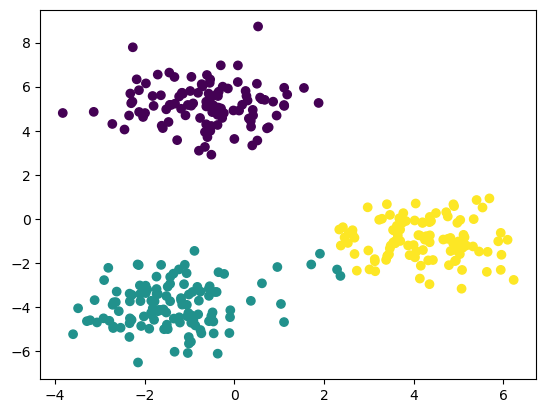

In [25]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)
plt.show()

##### Validating the k value 
#### Kneelocator
#### Silhoutee scoring


In [26]:
## kneelocator
!pip install kneed

In [27]:
from kneed import KneeLocator

In [28]:
kmeans.fit_predict(X_test_scaled)

c:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


array([1, 2, 2, 2, 2, 2, 1, 2, 0, 1, 0, 0, 2, 1, 1, 0, 0, 0, 2, 0, 2, 0,
       2, 0, 1, 1, 1, 2, 2, 2, 2, 2, 1, 2, 1, 0, 0, 0, 0, 2, 2, 2, 1, 2,
       1, 0, 0, 2, 0, 1, 0, 1, 2, 0, 0, 1, 1, 2, 2, 1, 2, 1, 0, 2, 1, 1,
       0, 2, 2, 2, 1, 0, 0, 2, 2, 0, 2, 1, 1, 0, 0, 1, 0, 2, 2, 0, 2, 0,
       2, 1, 0, 2, 2, 2, 0, 0, 2, 2, 0, 1, 2, 1, 0, 0, 0, 2, 1, 2, 0, 0,
       0, 2, 0, 0, 0, 1, 2, 0, 1, 2, 1, 0, 1, 2, 0, 1, 1, 1, 0, 1, 1, 2,
       1, 2, 2, 0, 1, 1, 1, 0, 1, 0, 0, 2, 2, 2, 0, 1, 2, 2, 1, 1, 2, 1,
       0, 1, 2, 0, 2, 0, 1, 2, 1, 1, 1, 1, 2, 1, 0, 2, 0, 2, 1, 0, 1, 2,
       0, 2, 2, 2, 2, 0, 0, 1, 0, 1, 2, 2, 0, 0, 0, 2, 1, 0, 2, 0, 0, 2,
       0, 1, 2, 2, 2, 0, 0, 2, 0, 0, 2, 0, 2, 1, 2, 0, 1, 0, 0, 2, 1, 0,
       2, 2, 0, 2, 2, 0, 1, 1, 1, 2, 1, 0, 2, 1, 2, 1, 1, 1, 2, 2, 2, 0,
       1, 1, 1, 2, 2, 0, 2, 1, 1, 0, 0, 1, 0, 2, 1, 2, 0, 1, 1, 2, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 2, 1, 2, 1, 2, 1, 2, 0, 0, 0, 0, 2, 1, 1,
       2, 2, 1, 1, 0, 2, 0, 2, 1, 2, 1, 0, 2, 1, 0,

In [31]:
kl = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [32]:
kl.elbow

np.int64(3)

In [33]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [36]:
silhouette_coefficients = []
for k in range(2,11):
  kmeans=KMeans(n_clusters=k,init="k-means++")
  kmeans.fit(X_train_scaled)
  score = silhouette_score(X_train_scaled,kmeans.labels_)
  silhouette_coefficients.append(score)

c:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

In [37]:
silhouette_coefficients

[np.float64(0.5034234136152262),
 np.float64(0.7474950730229215),
 np.float64(0.5741906840940821),
 np.float64(0.48558136647865213),
 np.float64(0.4834073286689236),
 np.float64(0.3478522987576787),
 np.float64(0.46534557393340237),
 np.float64(0.3516755154518783),
 np.float64(0.337352627353326)]

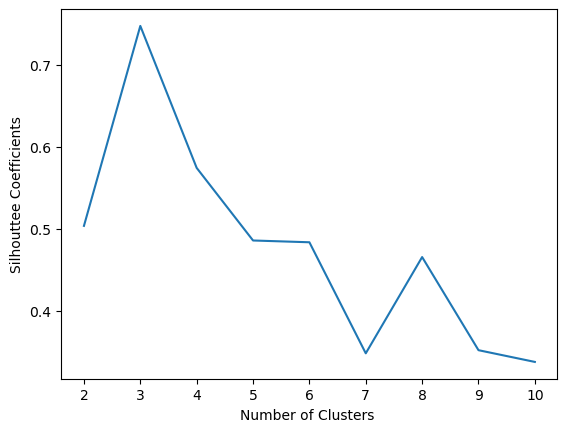

In [41]:
## Plotting silhoutte score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters ")
plt.ylabel("Silhouttee Coefficients")
plt.show()